[![](imagens/colab-badge.png){width="16%"}](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap03/cap03_aluno.ipynb)
[![](imagens/github-badge.png){width="20%"}](https://github.com/fzampirolli/pdi-vc)

# Operações Espaciais: Intensidade, Histograma e Filtragem

Este capítulo aprofunda o processamento de imagens no domínio espacial, partindo da manipulação direta de pixels e histogramas para o realce de contraste, até a aplicação de filtros locais por convolução para suavização, redução de ruído e detecção de bordas. O objetivo é desenvolver a intuição matemática e computacional que sustenta grande parte dos algoritmos modernos de Visão Computacional.

## Objetivos

Ao final deste capítulo, você será capaz de:

* **Manipular intensidade e pixels:** Executar operações aritméticas e lógicas (como subtração de fundo e máscaras bit a bit) e aplicar técnicas de realce por processamento de histograma (equalização e especificação);
* **Compreender fundamentos espaciais:** Entender os conceitos de vizinhança espacial, os mecanismos de convolução/correlação e o papel dos *kernels* (máscaras);
* **Aplicar filtragem espacial de suavização:** Utilizar filtros lineares de média e Gaussiano para redução de ruído e atenuação de detalhes;
* **Aplicar filtragem espacial de realce:** Dominar o uso de filtros de nitidez e bordas, como o Laplaciano, Sobel e a técnica de *Unsharp Masking*;
* **Utilizar filtros de ordem:** Aplicar o filtro de mediana para a remoção eficaz de ruídos específicos, como o ruído do tipo sal e pimenta;
* **Resolver problemas práticos:** Combinar essas técnicas de processamento e filtragem no pré-processamento de imagens para aplicações reais.

## Operações em Nível de Intensidade

O nível mais elementar de processamento de imagens atua diretamente sobre os valores dos pixels, sem considerar vizinhança. Essas operações — chamadas de **transformações de ponto** (*point operations*) — são as mais rápidas computacionalmente e formam a base para técnicas mais complexas.

Formalmente, uma transformação de ponto pode ser descrita como:

$$
g(x,y) = T[f(x,y)]
$$ {#eq-03-ponto}

onde $f(x,y)$ é a imagem de entrada, $g(x,y)$ é a saída e $T$ é uma função aplicada a cada pixel individualmente.

In [92]:
#| quarto-raw: true

import os, importlib, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Baixar morph.py se necessário
BASE_URL = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph"
for f in ["morph.py"]:
    if not os.path.exists(f):
        urllib.request.urlretrieve(f"{BASE_URL}/{f}", f)

import morph
importlib.reload(morph)
from morph import mm

print("✅ Ambiente pronto")

✅ Ambiente pronto


In [93]:
#| quarto-raw: true

# Carregar imagem de exemplo (Lena)
url_lena = "https://upload.wikimedia.org/wikipedia/en/7/7d/Lenna_%28test_image%29.png"
img_color = mm.read(url_lena)
img_gray = mm.gray(img_color)
print(f"Imagem original: {img_color.shape}")
print(f"Tipo da imagem: {type(img_gray)}")

Imagem original: (512, 512, 3)
Tipo da imagem: <class 'numpy.ndarray'>


### Operações Aritméticas

Operações aritméticas entre imagens são amplamente usadas em PDI para combinar, comparar ou realçar informações. A **subtração de imagens** é especialmente poderosa para detectar diferenças entre dois quadros — por exemplo, na remoção de fundo estático em câmeras de vigilância:

$$
g(x,y) = f_1(x,y) - f_2(x,y)
$$ {#eq-03-subtracao}

A **adição saturada** limita o resultado ao intervalo $[0, 255]$: valores acima de 255 são fixados em 255, evitando o *overflow* silencioso do tipo `uint8` (ex.: $200 + 100 = 44$ em vez de 300). A **subtração saturada** aplica o mesmo princípio pelo lado inferior: valores negativos são fixados em 0.

::: {.callout-warning}
### Saturação e *overflow* {.unnumbered}
Operações aritméticas em `uint8` sofrem *overflow* silencioso: $200 + 100 = 44$ (não 300). As funções `mm.addm` e `mm.subm` usam `cv2.add` e `cv2.subtract`, que realizam saturação automática. Para o *blending*, converta para `float32` antes de operar e aplique `np.clip(..., 0, 255).astype(np.uint8)` ao final, pois a operação envolve pesos fracionários.
:::

A @fig-03-aritmetica demonstra adição de uma constante (clareamento) e subtração de uma constante (escurecimento com saturação em 0).

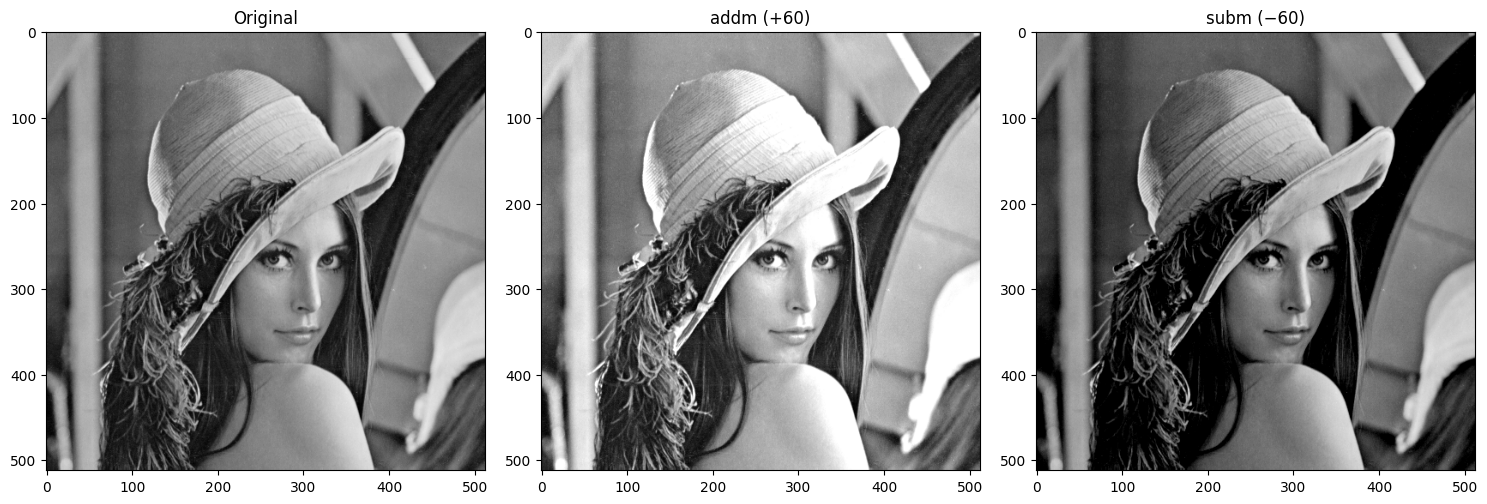

In [98]:
#| label: fig-03-aritmetica
#| fig-cap: "Operações aritméticas saturadas: adição de constante (clareamento) e subtração de constante (escurecimento com saturação em 0)."
#| echo: true
#| output: true

fundo = 60

img_add = mm.addm(img_gray, fundo)
img_sub = mm.subm(img_gray, fundo)

mm.show(
    [img_gray, img_add, img_sub],
    titles=["Original", "addm (+60)", "subm (−60)"],
    cols=3
)

### Mistura Ponderada (*Alpha Blending*)

A **mistura ponderada** combina duas imagens com pesos complementares $\alpha$ e $(1-\alpha)$:

$$
g(x,y) = \alpha\,f_1(x,y) + (1-\alpha)\,f_2(x,y), \quad \alpha \in [0,1]
$$ {#eq-03-blend}

Para $\alpha = 1$ obtém-se $f_1$ pura; para $\alpha = 0$, $f_2$ pura. Valores intermediários produzem uma fusão proporcional — útil em sobreposição de camadas, marcas d'água e transições suaves entre cenas.

Para que o *blending* seja visualmente coerente, é essencial alinhar as regiões de interesse das duas imagens antes de combiná-las. Na @fig-03-blend, recorta-se o rosto da Lena (`img_gray[100:-70, 220:-120]`) e a região dos olhos do leopardo de @fig-03-natureza (`img_numpy[250:-300, 100:-200]`), de forma que os olhares fiquem sobrepostos. O leopardo é então redimensionado para coincidir com o tamanho do recorte da Lena. A operação é realizada em `float32` para evitar *overflow*, com *clipping* final para `uint8`.

GPS Decimal: -19.140200, 23.814872
Maps: https://www.google.com/maps/search/?api=1&query=-19.1402,23.814872222222224

Tipo PIL: <class 'PIL.JpegImagePlugin.JpegImageFile'> | Dimensões (x,y): (1242, 1324)
Pillow (0,0) (x,y): (191, 135, 88)
Tipo NumPy: <class 'numpy.ndarray'> | Dimensões [y,x,c]: (1324, 1242, 3)
NumPy [0,0] [y,x]: [191 135  88]


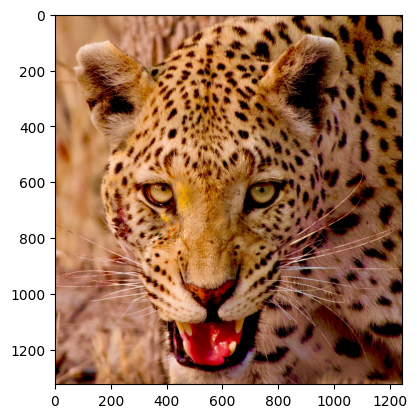

In [103]:
#| label: fig-03-natureza
#| fig-cap: "Leopard (Panthera pardus) GPS: (-19.14020, 23.81487). Crédito: C. Brück (CC BY-SA 4.0)."
#| echo: true

from PIL.ExifTags import TAGS
import numpy as np

base = "https://upload.wikimedia.org/wikipedia/commons"

arquivo = "Leopard_%28Panthera_pardus%29_portrait.jpg"

url = f"{base}/9/92/{arquivo}"

# 1. Leitura com metadados (PIL) e conversão para matriz (NumPy)
img_obj   = mm.read(url, info=True)
img_numpy = np.array(img_obj)

# 2. Extração e conversão de GPS (Tag 34853)
exif = img_obj._getexif()
if exif and (gps := exif.get(34853)):
    to_dec = lambda dms, ref: float(
        -(dms[0] + dms[1]/60 + dms[2]/3600) if ref in 'SW'
        else (dms[0] + dms[1]/60 + dms[2]/3600)
    )
    lat, lon = to_dec(gps[2], gps[1]), to_dec(gps[4], gps[3])
    print(f"GPS Decimal: {lat:.6f}, {lon:.6f}")
    print(f"Maps: https://www.google.com/maps/search/?api=1&query={lat},{lon}")

# 3. Diagnóstico de tipos, dimensões e acesso a pixels
print(f"\nTipo PIL: {type(img_obj)} | Dimensões (x,y): {img_obj.size}")
print(f"Pillow (0,0) (x,y): {img_obj.getpixel((0, 0))}")

print(f"Tipo NumPy: {type(img_numpy)} | Dimensões [y,x,c]: {img_numpy.shape}")
print(f"NumPy [0,0] [y,x]: {img_numpy[0, 0]}")

# 4. Exibição
mm.show(img_obj)

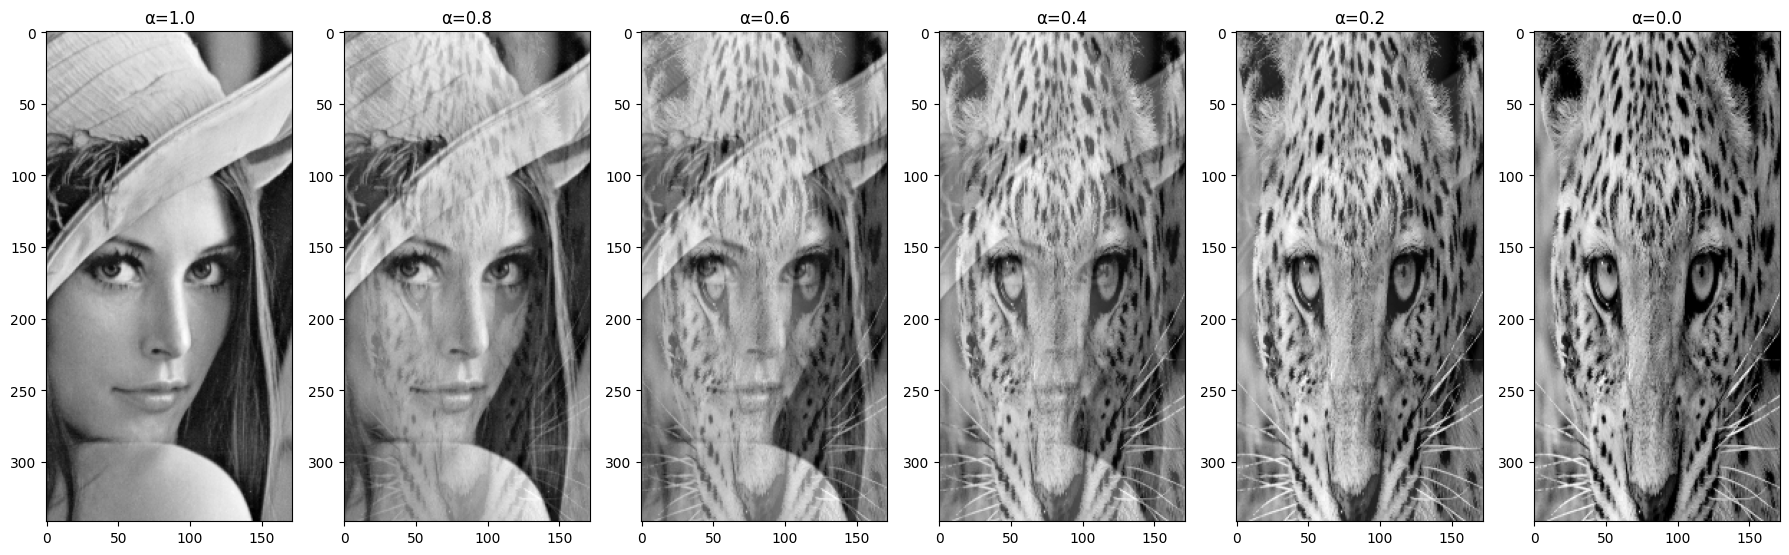

In [108]:
#| label: fig-03-blend
#| fig-cap: "*Alpha blending* entre recortes alinhados de Lena e do leopardo (@fig-03-natureza) para diferentes valores de α. Em α=1 vê-se apenas Lena; em α=0, apenas o leopardo; valores intermediários fundem os olhares das duas imagens proporcionalmente."
#| echo: true
#| output: true

leo = mm.gray(img_numpy)
leo = leo[250:-300, 100:-200]
lena = img_gray[100:-70, 220:-120]
img_leopardo = mm.resize(leo, (lena.shape[1], lena.shape[0]), method='bilinear')

alphas = [1.0, 0.8, 0.6, 0.4, 0.2, 0.0]
imgs_blend   = []
titles_blend = []

for a in alphas:
    imgs_blend.append(mm.blend(lena, img_leopardo, alpha=a))
    titles_blend.append(f"α={a:.1f}")

mm.show(imgs_blend, titles=titles_blend, cols=6, figsize=(18, 16))

### Operações Lógicas e Máscaras Bit a Bit

As operações lógicas bit a bit — AND, OR, XOR e NOT — operam nos bits de cada pixel e são amplamente usadas para criar e aplicar **máscaras** (*masks*). Uma máscara é uma imagem binária (0 ou 255) que seleciona regiões de interesse (ROI — *Region of Interest*).

A operação mais comum é a aplicação de uma máscara circular para isolar um objeto:

$$
g(x,y) = f(x,y) \;\text{AND}\; m(x,y)
$$ {#eq-03-mascara}

onde $m(x,y)$ é a máscara binária. O resultado preserva apenas os pixels onde $m = 255$, zerando o restante. O **NOT** inverte todas as intensidades bit a bit ($g = 255 - f$ para `uint8`), equivalendo a um negativo fotográfico. O **OR** com a máscara circular ilumina a região da máscara, fixando em 255 os pixels dentro do círculo e preservando os demais. A @fig-03-logica ilustra as três operações aplicadas à imagem Lena com uma máscara circular.

In [109]:
import morph
importlib.reload(morph)
from morph import mm

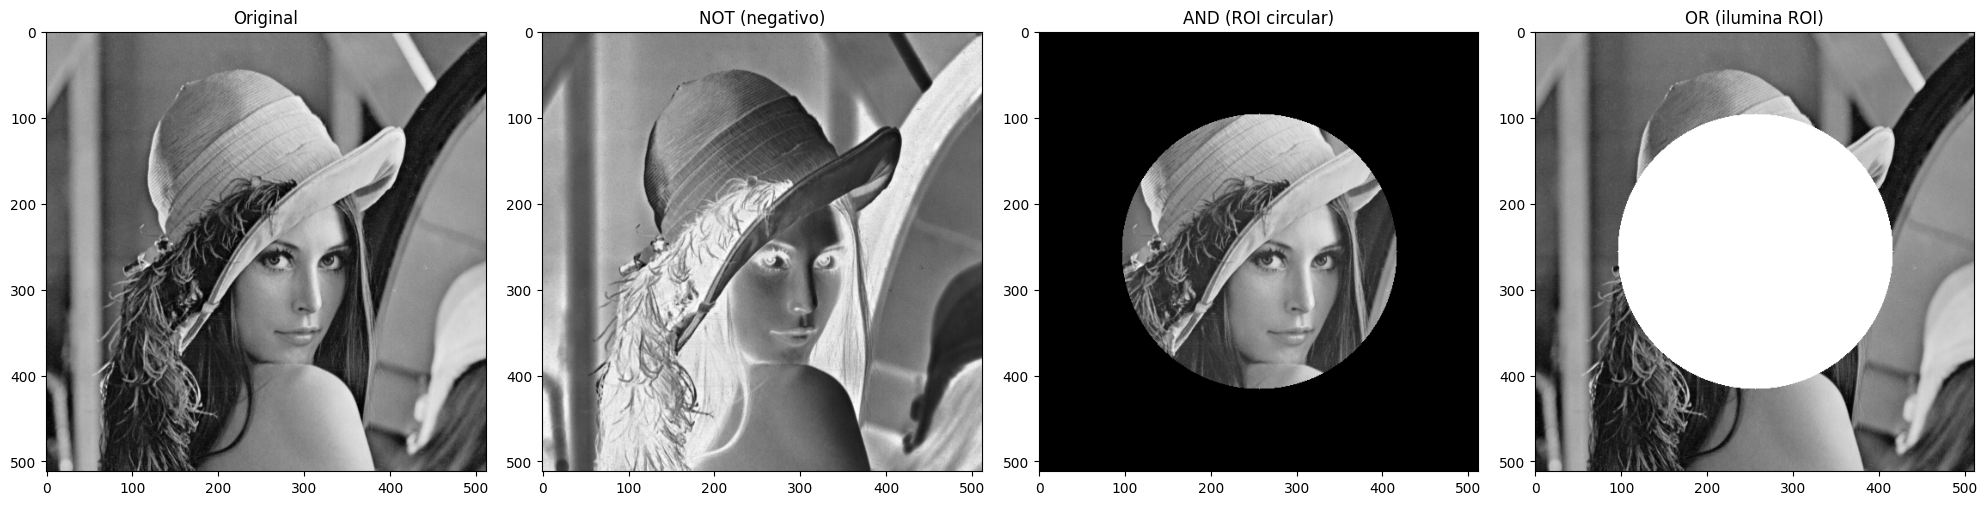

In [119]:
#| label: fig-03-logica
#| fig-cap: "Operações lógicas bit a bit com máscara circular: NOT (negativo), AND (isolamento da ROI) e OR (iluminação da ROI)."
#| echo: true
#| output: true

h, w = img_gray.shape

# Máscara circular centrada na imagem
mask_circ = np.zeros((h, w), dtype=np.uint8)
cv2.circle(mask_circ, (w//2, h//2), min(h, w)//3 - 10, 255, -1)

# Operações via morph
img_not = mm.bnot(img_gray)                  # NOT: negativo fotográfico
img_and = mm.band(img_gray, mask_circ)       # AND: preserva apenas a ROI circular
img_or  = mm.bor(img_gray, mask_circ)        # OR:  ilumina a região da máscara

mm.show(
    [img_gray, img_not, img_and, img_or],
    titles=["Original", "NOT (negativo)", "AND (ROI circular)", "OR (ilumina ROI)"],
    cols=4
)

## Histograma de Imagens

O **histograma** de uma imagem em tons de cinza é uma função discreta que descreve a distribuição de frequências das intensidades:

$$
h(r_k) = n_k, \quad k = 0, 1, \ldots, L-1
$$ {#eq-03-histograma}

onde $r_k$ é o $k$-ésimo nível de intensidade, $n_k$ é o número de pixels com essa intensidade e $L$ é o total de níveis (tipicamente 256 para 8 bits). A função de histograma normalizado (probabilidade estimada) é:

$$
p(r_k) = \frac{n_k}{MN}
$$ {#eq-03-hist-norm}

onde $MN$ é o total de pixels. O histograma é uma **estatística global** da imagem: não carrega informação posicional, mas revela características essenciais como brilho médio, contraste e distribuição tonal.

::: {.callout-note}
### Interpretação do Histograma {.unnumbered}
- **Histograma estreito e deslocado à esquerda:** imagem subexposta (escura).
- **Histograma estreito e deslocado à direita:** imagem superexposta (clara).
- **Histograma concentrado no centro:** baixo contraste.
- **Histograma distribuído ao longo de toda a faixa:** alto contraste, boa utilização dos tons disponíveis.
:::

A @fig-03-histograma exibe o histograma da imagem Lena e de versões com contraste modificado.

In [ ]:
#| label: fig-03-histograma
#| fig-cap: "Histogramas da imagem original, de uma versão escurecida e de uma versão com contraste aumentado. Observe o deslocamento e o espalhamento da distribuição."
#| echo: true
#| output: true

# Versões modificadas
img_dark  = np.clip(img_gray.astype(np.int32) - 80, 0, 255).astype(np.uint8)
img_high  = np.clip((img_gray.astype(np.float32) - 128) * 2.0 + 128, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

images = [img_gray, img_dark, img_high]
titles = ["Original", "Escurecida (-80)", "Alto Contraste (×2)"]

for col, (img, title) in enumerate(zip(images, titles)):
    axes[0, col].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(title)
    axes[0, col].axis("off")
    axes[1, col].hist(img.ravel(), bins=256, range=(0, 256), color="steelblue", edgecolor="none")
    axes[1, col].set_xlim(0, 255)
    axes[1, col].set_xlabel("Intensidade")
    axes[1, col].set_ylabel("Frequência")
    axes[1, col].set_title(f"Histograma — {title}")

plt.tight_layout()
plt.show()

### Equalização de Histograma

A **equalização de histograma** é uma técnica automática de realce de contraste que redistribui as intensidades para que o histograma resultante seja o mais uniforme possível. O mapeamento é realizado pela **função de distribuição acumulada (CDF)**:

$$
s_k = T(r_k) = (L-1)\sum_{j=0}^{k} p(r_j) = \frac{(L-1)}{MN}\sum_{j=0}^{k} n_j
$$ {#eq-03-equalizacao}

Essa transformação é monotônica e garante que os níveis de saída sejam distribuídos mais uniformemente, melhorando o contraste global sem intervenção manual do usuário.

**Limitação:** a equalização global pode super-realçar ruídos em regiões homogêneas. A técnica **CLAHE** (*Contrast Limited Adaptive Histogram Equalization*) resolve isso aplicando a equalização em blocos locais com limitação do *clip* de contraste.

A @fig-03-equalizacao compara a equalização global e o CLAHE.

In [ ]:
#| label: fig-03-equalizacao
#| fig-cap: "Equalização de histograma: global (OpenCV) vs. CLAHE (adaptativa com limitação de contraste). Observe o melhor contraste local com CLAHE sem artefatos excessivos."
#| echo: true
#| output: true

# Equalização global
img_eq = cv2.equalizeHist(img_gray)

# CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(img_gray)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

images = [img_gray, img_eq, img_clahe]
titles = ["Original", "Equalização Global", "CLAHE"]

for col, (img, title) in enumerate(zip(images, titles)):
    axes[0, col].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(title)
    axes[0, col].axis("off")
    axes[1, col].hist(img.ravel(), bins=256, range=(0, 256), color="steelblue", edgecolor="none")
    axes[1, col].set_xlim(0, 255)
    axes[1, col].set_xlabel("Intensidade")
    axes[1, col].set_title(f"Histograma — {title}")

plt.tight_layout()
plt.show()

### Especificação de Histograma

Enquanto a equalização impõe uma distribuição uniforme, a **especificação de histograma** (*histogram matching*) permite que o histograma da imagem de saída siga uma distribuição **arbitrária** pré-definida — por exemplo, a distribuição de outra imagem de referência.

O procedimento envolve três etapas:

1. Calcular a CDF da imagem de entrada: $P_r(r_k)$.
2. Calcular a CDF do histograma alvo: $P_z(z_k)$.
3. Determinar o mapeamento $T$ tal que $P_z(T(r_k)) = P_r(r_k)$, encontrando para cada $s_k = P_r(r_k)$ o nível $z$ que minimiza $|P_z(z) - s_k|$.

Na @fig-03-especificacao, aplicamos a especificação para que a imagem Lena assuma o perfil tonal de uma distribuição Gaussiana centrada em 180 (simulando uma imagem mais clara e suave), comparando com a equalização padrão.

In [ ]:
#| label: fig-03-especificacao
#| fig-cap: "Especificação de histograma: mapeamento da imagem Lena para uma distribuição Gaussiana alvo (μ=180, σ=40), comparada à equalização global."
#| echo: true
#| output: true

def hist_specify(img, target_hist):
    """Aplica especificação de histograma dado um histograma alvo normalizado."""
    # CDF da imagem de entrada
    hist_src, _ = np.histogram(img.ravel(), 256, [0, 256])
    cdf_src = hist_src.cumsum()
    cdf_src = cdf_src / cdf_src[-1]  # normaliza

    # CDF do alvo
    cdf_tgt = target_hist.cumsum()
    cdf_tgt = cdf_tgt / cdf_tgt[-1]

    # Mapeamento: para cada valor src, encontra o valor tgt de CDF mais próxima
    lut = np.searchsorted(cdf_tgt, cdf_src)
    return lut[img].astype(np.uint8)

# Histograma alvo: Gaussiana centrada em 180
x = np.arange(256)
mu, sigma = 180, 40
target = np.exp(-0.5 * ((x - mu) / sigma) ** 2)
target = target / target.sum()

img_spec = hist_specify(img_gray, target)
img_eq   = cv2.equalizeHist(img_gray)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
images = [img_gray, img_eq, img_spec]
titles = ["Original", "Equalização Global", "Especificação (Gaussiana, μ=180)"]

for col, (img, title) in enumerate(zip(images, titles)):
    axes[0, col].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(title)
    axes[0, col].axis("off")
    axes[1, col].hist(img.ravel(), bins=256, range=(0, 256), color="steelblue", edgecolor="none")
    axes[1, col].set_xlim(0, 255)
    axes[1, col].set_xlabel("Intensidade")
    axes[1, col].set_title(f"Histograma — {title}")

plt.tight_layout()
plt.show()

## Fundamentos Espaciais: Vizinhança, Convolução e Kernels

As operações de filtragem espacial operam sobre **regiões vizinhas** de pixels — não mais pixel a pixel. O conceito central é a **janela deslizante** (*sliding window*): um *kernel* (também chamado de máscara ou filtro) percorre toda a imagem, e para cada posição $(x,y)$ calcula uma nova intensidade combinando os pixels da vizinhança ponderados pelos coeficientes do *kernel*.

### Convolução e Correlação

Existem dois mecanismos matematicamente relacionados:

**Correlação cruzada** (*cross-correlation*):

$$
g(x,y) = \sum_{s=-a}^{a}\sum_{t=-b}^{b} w(s,t)\,f(x+s,\,y+t)
$$ {#eq-03-correlacao}

**Convolução bidimensional**:

$$
g(x,y) = \sum_{s=-a}^{a}\sum_{t=-b}^{b} w(s,t)\,f(x-s,\,y-t)
$$ {#eq-03-convolucao}

A diferença é a **rotação de 180°** do *kernel* na convolução em relação à correlação. Para *kernels* simétricos (como Gaussiano, Laplaciano e de média), as duas operações produzem resultados idênticos. Para *kernels* assimétricos (como Sobel), a diferença é significativa.

::: {.callout-note}
### Correlação vs. Convolução no OpenCV {.unnumbered}
A função `cv2.filter2D` implementa **correlação** (não convolução). Para obter convolução verdadeira com um *kernel* assimétrico, rotacione o *kernel* 180° antes de passar para `filter2D`, ou use `scipy.ndimage.convolve`.
:::

### O Papel do *Kernel*

O *kernel* $w$ de dimensão $(2a+1) \times (2b+1)$ codifica a operação desejada:

| Operação | Efeito sobre o *kernel* |
|:---------|:------------------------|
| Soma = 1, coefs. positivos | Suavização (passa-baixa) |
| Soma = 0, coefs. positivos e negativos | Detecção de bordas (passa-alta) |
| Soma = 1, centro > 1, bordas < 0 | Realce de nitidez |
| Valor absoluto da diferença | Gradiente direcional |

: Interpretação dos coeficientes do *kernel* em filtros espaciais. {#tbl-03-kernels}

A @fig-03-convolucao-passo ilustra o mecanismo de convolução passo a passo em uma pequena matriz.

In [ ]:
#| label: fig-03-convolucao-passo
#| fig-cap: "Visualização do mecanismo de convolução: o kernel 3×3 de média percorre a imagem Lena (à esquerda) gerando a saída suavizada (à direita). Os valores mostram o kernel normalizado e o resultado central da primeira aplicação."
#| echo: true
#| output: true

# Demonstração manual: convolução em um patch 5x5
patch = img_gray[250:255, 250:255].astype(np.float32)
kernel_mean = np.ones((3, 3), dtype=np.float32) / 9.0

print("Patch 5×5 original (intensidades):")
print(patch.astype(np.int32))

# Aplicação manual no pixel central (2,2)
roi = patch[0:3, 0:3]  # vizinhança 3×3
resultado = np.sum(roi * kernel_mean)
print(f"\nKernel 3×3 de média:\n{kernel_mean}")
print(f"\nConvolução no pixel central: {resultado:.1f} (original: {patch[1,1]:.0f})")

# Aplicação completa com filter2D
img_conv = cv2.filter2D(img_gray, -1, kernel_mean)
mm.show([img_gray, img_conv],
        titles=["Original", "Após Convolução (kernel média 3×3)"],
        cols=2)

## Filtragem Espacial de Suavização

Os filtros de suavização (*smoothing filters*) atenuam variações bruscas de intensidade, reduzindo ruído e detalhes de alta frequência. São filtros **passa-baixa** — preservam as componentes de baixa frequência (estruturas grandes) e atenuam as de alta frequência (ruído, bordas).

### Filtro de Média (*Box Filter*)

O filtro de média mais simples utiliza um *kernel* uniforme de tamanho $n \times n$:

$$
w_{\text{média}} = \frac{1}{n^2}
\begin{bmatrix}
1 & \cdots & 1 \\
\vdots & \ddots & \vdots \\
1 & \cdots & 1
\end{bmatrix}_{n \times n}
$$ {#eq-03-media}

Cada pixel de saída é a média aritmética dos pixels de sua vizinhança $n \times n$. Kernels maiores produzem suavização mais agressiva, mas borram mais as bordas.

A @fig-03-media compara o efeito de kernels de média com diferentes tamanhos.

In [ ]:
#| label: fig-03-media
#| fig-cap: "Filtro de média com kernels de tamanho crescente (3×3, 7×7, 15×15). Observe o crescente borramento das bordas com o aumento do tamanho do kernel."
#| echo: true
#| output: true

sizes = [3, 7, 15]
imgs_media = []
titles_media = ["Original"]

for k in sizes:
    kernel = np.ones((k, k), dtype=np.float32) / (k * k)
    imgs_media.append(cv2.filter2D(img_gray, -1, kernel))
    titles_media.append(f"Média {k}×{k}")

mm.show([img_gray] + imgs_media, titles=titles_media, cols=4)

### Filtro Gaussiano

O filtro Gaussiano pesa os pixels da vizinhança de acordo com uma função Gaussiana bidimensional:

$$
G(s,t) = \frac{1}{2\pi\sigma^2}\,e^{-\frac{s^2+t^2}{2\sigma^2}}
$$ {#eq-03-gaussiana}

onde $\sigma$ é o desvio padrão e controla o raio de influência. Pixels mais próximos do centro têm peso maior; pixels distantes são progressivamente ignorados. Comparado ao filtro de média, o Gaussiano:

- Preserva melhor as bordas (borramento mais suave e gradual);
- É separável: $G(s,t) = G(s)\cdot G(t)$, permitindo implementação eficiente em duas passagens 1D;
- É o único filtro que não introduz anéis (*ringing*) na frequência.

A @fig-03-gauss compara média e Gaussiano no detalhe da imagem, evidenciando a preservação de bordas.

In [ ]:
#| label: fig-03-gauss
#| fig-cap: "Comparação entre filtro de média e Gaussiano (ambos com janela 9×9). O Gaussiano suaviza com menos borramento das bordas, visível no detalhe do olho."
#| echo: true
#| output: true

# Filtro de média 9x9
kernel9 = np.ones((9, 9), dtype=np.float32) / 81.0
img_media9 = cv2.filter2D(img_gray, -1, kernel9)

# Filtro Gaussiano 9x9
img_gauss9 = cv2.GaussianBlur(img_gray, (9, 9), 0)

# Recorte do olho para comparação de detalhes
y, x, off = 265, 265, 40
crop_orig  = img_gray[y-off:y+off, x-off:x+off]
crop_media = img_media9[y-off:y+off, x-off:x+off]
crop_gauss = img_gauss9[y-off:y+off, x-off:x+off]

# Ampliação para visualização
amp = lambda c: mm.resize(c, 3, method="nearest")

mm.show(
    [img_gray, img_media9, img_gauss9,
     amp(crop_orig), amp(crop_media), amp(crop_gauss)],
    titles=["Original", "Média 9×9", "Gaussiano 9×9",
            "Detalhe: Original", "Detalhe: Média", "Detalhe: Gaussiano"],
    cols=3
)

## Filtragem Espacial de Realce

Os filtros de realce (*sharpening filters*) enfatizam transições abruptas de intensidade, aumentando a nitidez e a visibilidade de bordas. São filtros **passa-alta** — amplificam as componentes de alta frequência (bordas, textura) e suprimem as de baixa frequência (regiões uniformes).

### Laplaciano

O Laplaciano é um operador de segunda derivada que responde a variações bruscas em todas as direções:

$$
\nabla^2 f = \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partial y^2}
$$ {#eq-03-laplaciano}

Na forma discreta, aproxima-se por um *kernel* 3×3. Existem duas variantes comuns:

$$
w_4 = \begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix}, \qquad
w_8 = \begin{bmatrix} 1 & 1 & 1 \\ 1 & -8 & 1 \\ 1 & 1 & 1 \end{bmatrix}
$$ {#eq-03-laplaciano-kernel}

A imagem realçada é obtida somando o Laplaciano à original (com sinal negativo quando o centro do *kernel* é negativo):

$$
g(x,y) = f(x,y) - \nabla^2 f(x,y)
$$ {#eq-03-realce-lap}

A @fig-03-laplaciano ilustra a resposta do Laplaciano e a imagem realçada.

In [ ]:
#| label: fig-03-laplaciano
#| fig-cap: "Realce com Laplaciano: (esq.) imagem original, (centro) resposta do Laplaciano (bordas detectadas), (dir.) imagem realçada pela subtração do Laplaciano."
#| echo: true
#| output: true

# Kernel Laplaciano 4-vizinhos
kernel_lap = np.array([[0, 1, 0],
                        [1,-4, 1],
                        [0, 1, 0]], dtype=np.float32)

# Aplicar Laplaciano
img_f32 = img_gray.astype(np.float32)
lap = cv2.filter2D(img_f32, cv2.CV_32F, kernel_lap)

# Realce: subtrai o Laplaciano (centro negativo → subtrai → realça)
img_realce = np.clip(img_f32 - lap, 0, 255).astype(np.uint8)

# Laplaciano normalizado para visualização
lap_viz = np.clip(np.abs(lap) / np.abs(lap).max() * 255, 0, 255).astype(np.uint8)

mm.show(
    [img_gray, lap_viz, img_realce],
    titles=["Original", "Laplaciano (bordas)", "Realce (f - ∇²f)"],
    cols=3
)

### Operador de Sobel

O operador de Sobel estima as derivadas parciais de primeira ordem da imagem nas direções horizontal e vertical, usando *kernels* que combinam suavização Gaussiana com derivada direcional:

$$
G_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix} * f, \qquad
G_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix} * f
$$ {#eq-03-sobel}

A magnitude do **gradiente** combina os dois componentes e representa a força da borda em cada ponto:

$$
|\nabla f| = \sqrt{G_x^2 + G_y^2}
$$ {#eq-03-gradiente}

A **direção** do gradiente, perpendicular à borda, é:

$$
\theta = \arctan\left(\frac{G_y}{G_x}\right)
$$ {#eq-03-direcao}

A @fig-03-sobel mostra os componentes direcionais e a magnitude do gradiente para a imagem Lena.

In [ ]:
#| label: fig-03-sobel
#| fig-cap: "Operador de Sobel: componentes horizontal (Gx), vertical (Gy) e magnitude do gradiente. As bordas são regiões de alta magnitude."
#| echo: true
#| output: true

sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
magnitude = np.sqrt(sobelx**2 + sobely**2)

# Normalização para visualização
def norm255(img):
    mn, mx = img.min(), img.max()
    return ((img - mn) / (mx - mn + 1e-9) * 255).astype(np.uint8)

mm.show(
    [img_gray, norm255(np.abs(sobelx)), norm255(np.abs(sobely)), norm255(magnitude)],
    titles=["Original", "Sobel Gx (horizontal)", "Sobel Gy (vertical)", "Magnitude |∇f|"],
    cols=4
)

### *Unsharp Masking* (USM)

O *Unsharp Masking* é uma técnica clássica de realce de nitidez originária da fotografia analógica, hoje amplamente usada em software de edição de imagens. O processo é:

1. **Suavizar** a imagem original: $\bar{f} = f * G_\sigma$ (convolução com Gaussiana);
2. **Calcular a máscara não-nitida**: $m(x,y) = f(x,y) - \bar{f}(x,y)$ (componentes de alta frequência);
3. **Somar a máscara ponderada**: $g(x,y) = f(x,y) + k \cdot m(x,y)$.

$$
g = f + k\,(f - f*G_\sigma) = (1+k)f - k\,(f*G_\sigma)
$$ {#eq-03-usm}

O parâmetro $k$ controla a intensidade do realce: $k=1$ corresponde ao USM clássico; $k>1$ produz *high boost filtering*. A @fig-03-usm compara diferentes valores de $k$.

In [ ]:
#| label: fig-03-usm
#| fig-cap: "Unsharp Masking com diferentes fatores k: k=0.5 (suave), k=1.0 (clássico) e k=2.0 (High Boost). Maior k aumenta a nitidez mas também amplifica ruídos."
#| echo: true
#| output: true

def unsharp_mask(img, sigma=2.0, k=1.0):
    """Aplica Unsharp Masking com parâmetro de realce k."""
    ksize = int(6 * sigma + 1) | 1  # garante tamanho ímpar
    suav  = cv2.GaussianBlur(img.astype(np.float32), (ksize, ksize), sigma)
    mask  = img.astype(np.float32) - suav
    return np.clip(img.astype(np.float32) + k * mask, 0, 255).astype(np.uint8)

ks = [0.5, 1.0, 2.0]
imgs_usm = [unsharp_mask(img_gray, sigma=2.0, k=k) for k in ks]
titles_usm = [f"USM k={k}" for k in ks]

mm.show(
    [img_gray] + imgs_usm,
    titles=["Original"] + titles_usm,
    cols=4
)

## Filtros de Ordem: Filtro da Mediana

Os filtros de ordem (*order-statistic filters*) substituem o pixel central pelo valor de um **percentil** da distribuição de intensidades da vizinhança — ao contrário dos filtros lineares, que calculam combinações ponderadas. O mais importante é o **filtro da mediana**.

### Ruído Impulsivo: Sal e Pimenta

O ruído **sal e pimenta** (*salt-and-pepper noise*) é um tipo de ruído impulsivo que substitui pixels aleatórios por valores extremos: 0 (pimenta) ou 255 (sal). É comum em transmissão de imagens com erros de bit e em câmeras com sensores defeituosos.

::: {.callout-warning}
### Por que filtros de média falham com ruído impulsivo? {.unnumbered}
Um único pixel com valor 255 em uma vizinhança de 9 pixels com valor ≈ 100 eleva a média para ≈ 128, espalhando o ruído. A mediana, por ser um **estimador robusto**, ignora os valores extremos ao selecionar o valor central da distribuição ordenada.
:::

O experimento na @fig-03-ruido demonstra a adição de ruído sal e pimenta com diferentes densidades.

In [ ]:
#| label: fig-03-ruido
#| fig-cap: "Ruído sal e pimenta com densidades crescentes (2%, 5%, 10%). O parâmetro prob indica a fração de pixels corrompidos."
#| echo: true
#| output: true

def add_salt_pepper(img, prob=0.05):
    """Adiciona ruído sal e pimenta com probabilidade total prob."""
    noisy = img.copy()
    rnd   = np.random.default_rng(42).random(img.shape)
    noisy[rnd < prob / 2]      = 0    # pimenta (preto)
    noisy[rnd > 1 - prob / 2]  = 255  # sal (branco)
    return noisy

probs = [0.02, 0.05, 0.10]
imgs_noise = [add_salt_pepper(img_gray, p) for p in probs]
titles_noise = [f"Ruído: {int(p*100)}%" for p in probs]

mm.show([img_gray] + imgs_noise, titles=["Original"] + titles_noise, cols=4)

### Filtro da Mediana

O filtro da mediana substitui cada pixel pelo **valor mediano** dos pixels da sua vizinhança $n \times n$:

$$
g(x,y) = \text{med}_{(s,t) \in \mathcal{V}_{n}} \{f(x+s, y+t)\}
$$ {#eq-03-mediana}

O valor mediano é aquele que ocupa a posição central quando os $n^2$ valores da vizinhança são ordenados. Por ser baseado em ordenação e não em soma, a mediana é:

- **Robusta** ao ruído impulsivo (ignora valores extremos);
- **Preservadora de bordas** (não borra transições abruptas como o filtro de média);
- **Não linear** (não pode ser expressa como convolução).

A @fig-03-mediana compara a eficiência do filtro de média e da mediana na remoção de ruído sal e pimenta.

In [ ]:
#| label: fig-03-mediana
#| fig-cap: "Comparação entre filtro de média e mediana para remoção de ruído sal e pimenta (densidade 5%). A mediana remove o ruído preservando bordas; a média espalha os pixels corrompidos."
#| echo: true
#| output: true

img_noise5 = add_salt_pepper(img_gray, prob=0.05)

# Filtro de média 3x3
kernel3 = np.ones((3, 3), dtype=np.float32) / 9.0
img_media_dn  = cv2.filter2D(img_noise5, -1, kernel3)

# Filtro da mediana 3x3 e 5x5
img_med3 = cv2.medianBlur(img_noise5, 3)
img_med5 = cv2.medianBlur(img_noise5, 5)

mm.show(
    [img_gray, img_noise5, img_media_dn, img_med3, img_med5],
    titles=["Original", "Ruído 5%", "Média 3×3", "Mediana 3×3", "Mediana 5×5"],
    cols=5
)

## Aplicação Prática: Pré-processamento para Segmentação

Na prática, as técnicas deste capítulo raramente são usadas isoladamente. Um **pipeline de pré-processamento** típico combina várias etapas em sequência, adaptando-se ao tipo de imagem e à aplicação. A @fig-03-pipeline ilustra um pipeline completo:

1. **Equalização de histograma (CLAHE):** normaliza o contraste independente das condições de iluminação;
2. **Filtro Gaussiano:** suaviza ruído de aquisição sem destruir bordas;
3. **Detecção de bordas (Sobel/Canny):** extrai estruturas relevantes para segmentação.

::: {.callout-note}
### Ordem importa {.unnumbered}
A ordem das operações afeta o resultado final. Em geral: **(1) normalização de intensidade → (2) redução de ruído → (3) realce/segmentação**. Inverter a ordem pode amplificar ruído ou perder bordas antes de detectá-las.
:::

In [ ]:
#| label: fig-03-pipeline
#| fig-cap: "Pipeline de pré-processamento: CLAHE → Gaussiano → Canny. Cada etapa prepara a imagem para a seguinte, resultando em bordas limpas e bem definidas."
#| echo: true
#| output: true

# Etapa 1: CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(img_gray)

# Etapa 2: Gaussiano
img_gauss = cv2.GaussianBlur(img_clahe, (5, 5), 0)

# Etapa 3: Canny
edges = cv2.Canny(img_gauss, 50, 150)

# Comparação: pipeline vs. Canny direto
edges_direct = cv2.Canny(img_gray, 50, 150)

mm.show(
    [img_gray, img_clahe, img_gauss, edges, edges_direct],
    titles=["Original", "1. CLAHE", "2. Gaussiano", "3. Canny (pipeline)", "Canny (direto)"],
    cols=5
)

## Resumo

Neste capítulo foram apresentadas as principais técnicas de processamento no domínio espacial:

- **Operações de ponto:** transformações aritméticas (adição, subtração, blending) e lógicas (AND, OR, NOT) para manipulação direta de pixels.
- **Histograma:** ferramenta diagnóstica que descreve a distribuição de intensidades; base para equalização global e CLAHE (adaptativa).
- **Especificação de histograma:** transferência do perfil tonal de uma distribuição alvo usando o mapeamento pela CDF.
- **Convolução e correlação:** mecanismo de janela deslizante que implementa filtros lineares; diferenciados pela rotação do *kernel*.
- **Filtros de suavização:** média (uniforme) e Gaussiano (ponderado); o Gaussiano preserva melhor as bordas.
- **Filtros de realce:** Laplaciano (segunda derivada), Sobel (gradiente direcional) e *Unsharp Masking* (amplificação de alta frequência).
- **Filtro da mediana:** estimador robusto, não linear, eficiente contra ruído sal e pimenta com preservação de bordas.
- **Pipeline prático:** encadeamento de técnicas (CLAHE → Gaussiano → Canny) como estratégia de pré-processamento para aplicações reais.

O Capítulo 4 abordará o **processamento no domínio da frequência** (Transformada de Fourier) e a **morfologia matemática** (erosão, dilatação, abertura, fechamento).

## 🤖 Uso do NotebookLM como Tutor Complementar

Nesta edição, incentivamos o uso do **NotebookLM** como ferramenta complementar de aprendizagem. Essa ferramenta de IA utiliza exclusivamente os documentos fornecidos pelo autor como base de conhecimento, garantindo respostas coerentes com o conteúdo do livro.

Para cada capítulo, preparamos um projeto específico na plataforma. Para uma experiência de estudo ampliada, utilize o acesso abaixo:

::: {.callout-important appearance="default" icon=false}
### 🎓 Estude com o Tutor Inteligente {.unnumbered}

Para interagir com o conteúdo deste capítulo, acesse o link a seguir. O ambiente contém materiais didáticos em diferentes formatos, gerados a partir do **PDF** do capítulo. Na plataforma, explore especialmente as opções **Guia de Estudo** e **Conversa** para aprofundar sua compreensão.

[🚀 ACESSAR NOTEBOOKLM: CAPÍTULO 03](https://notebooklm.google.com/notebook/cap03)
:::

## Lista de Exercícios

1. **(10%)** Explique a diferença entre **convolução** e **correlação cruzada**. Para quais tipos de *kernel* os resultados são idênticos? Dê um exemplo de *kernel* onde as operações diferem.

2. **(15%)** Considere uma imagem com histograma fortemente concentrado entre os níveis 50 e 150. Descreva matematicamente o mapeamento que a equalização de histograma aplicaria. Calcule os novos níveis para $r = 50$, $r = 100$ e $r = 150$, assumindo que os pixels estão uniformemente distribuídos nesse intervalo.

3. **(15%)** Usando o código do laboratório, aplique o filtro de média com kernels de tamanho 3×3, 9×9 e 21×21. Compare quantitativamente os resultados calculando o **PSNR** (*Peak Signal-to-Noise Ratio*) entre a imagem original e cada versão filtrada. O que a queda do PSNR indica?

4. **(15%)** Adicione ruído sal e pimenta com densidade de 5% e aplique: (a) filtro de média 3×3, (b) filtro Gaussiano $\sigma=1$, (c) mediana 3×3 e (d) mediana 5×5. Compare visualmente e explique por que a mediana supera os filtros lineares nesse cenário.

5. **(15%)** Implemente manualmente (sem `cv2.filter2D`) a correlação cruzada de um *kernel* de média 3×3 em uma imagem de escala de cinza utilizando apenas operações NumPy vetorizadas (sem laços Python). Compare o resultado e o tempo de execução com a versão `cv2.filter2D`.

6. **(15%)** Aplique o *Unsharp Masking* com $\sigma = 1$ e $k = \{0.5, 1.0, 2.0, 4.0\}$. Para cada valor, calcule a diferença absoluta em relação à imagem original e exiba os histogramas dessas diferenças. O que acontece com os artefatos quando $k$ é muito alto?

7. **(15%)** Projete um pipeline de pré-processamento para uma imagem médica (raio-X, por exemplo) com objetivo de realçar estruturas internas. Justifique cada etapa escolhida com base nos conceitos do capítulo e demonstre o resultado.

## Referências do Capítulo {.unnumbered}

A fundamentação teórica deste capítulo baseia-se nas seguintes obras:

* @gonzalez2018digital para os conceitos de operações de intensidade, histograma, convolução e filtragem espacial.
* @szeliski2022 para a visão computacional e aplicações práticas de filtragem.
* @bradski2008learning para a implementação prática com OpenCV e `morph.py`.